# CertCF scaling on pretrained CIFAR-10 ResNets

This notebook analyzes already-computed per-network artifacts. It never builds an atlas or runs a query. The official protocol uses 10,000 balanced CIFAR-10 training images as atlas anchors, 100 shared balanced queries, and top-$k=3$.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
RESULTS = ROOT / 'results' / 'cifar_resnet_scaling'
queries = pd.read_parquet(RESULTS / 'cifar_resnet_queries.parquet')
summary = pd.read_parquet(RESULTS / 'cifar_resnet_summary.parquet')
NETWORK_ORDER = ['resnet20', 'resnet32', 'resnet56']
summary = summary.set_index('network').loc[NETWORK_ORDER].reset_index()
assert len(queries) == 300 and queries['network'].nunique() == 3
summary

,network,adaptive_shrinks_max,adaptive_shrinks_mean,atlas_region_count,atlas_region_counts_by_class,attempted_anchor_count,build_attempt_wall_time_s,build_cuda_peak_allocated_bytes,build_cuda_peak_reserved_bytes,build_rss_baseline_bytes,...,mean_l1,mean_l2,mean_linf,mean_psnr,mean_ssim,empirical_robustness,mean_certified_l1_radius,mean_certified_l2_radius,mean_certified_linf_radius,fallback_rate
0,resnet20,0,0.0,10000,"{'0': 1000, '1': 999, '2': 1000, '3': 1001, '4...",10000,338.641303,464612352,482344960,1515155456,...,356.274034,8.784858,0.620743,16.218270,0.348838,1.0,0.000042,7.618630e-07,1.378607e-08,0.0
1,resnet32,0,0.0,10000,"{'0': 1001, '1': 1000, '2': 1000, '3': 1000, '...",10000,456.726892,732421120,752877568,1516371968,...,356.274036,8.788158,0.620876,16.213672,0.348651,1.0,0.000045,8.088973e-07,1.462291e-08,0.0
2,resnet56,0,0.0,10000,"{'0': 1000, '1': 1000, '2': 1000, '3': 1000, '...",10000,755.228776,1268038656,1293942784,1517232128,...,356.274029,8.781873,0.619818,16.220943,0.348923,1.0,0.000036,6.527571e-07,1.180184e-08,0.0


## Complete per-network results

In [3]:
columns = ['network', 'parameter_count', 'relu_activation_count', 'classifier_test_accuracy',
           'build_wall_time_s', 'build_rss_peak_delta_bytes', 'build_cuda_peak_allocated_bytes',
           'atlas_region_count', 'uncertified_anchor_fraction', 'eps_initial_median',
           'eps_final_median', 'eps_ratio_median', 'success_rate', 'validity',
           'mean_l1', 'mean_l2', 'mean_linf', 'mean_psnr', 'mean_ssim',
           'empirical_robustness', 'mean_certified_l1_radius',
           'mean_certified_l2_radius', 'mean_certified_linf_radius',
           'query_time_median_s', 'query_time_p95_s']
summary[[c for c in columns if c in summary.columns]].style.format(precision=4)

,network,parameter_count,relu_activation_count,classifier_test_accuracy,build_wall_time_s,build_rss_peak_delta_bytes,build_cuda_peak_allocated_bytes,atlas_region_count,uncertified_anchor_fraction,eps_initial_median,eps_final_median,eps_ratio_median,success_rate,validity,mean_l1,mean_l2,mean_linf,mean_psnr,mean_ssim,empirical_robustness,mean_certified_l1_radius,mean_certified_l2_radius,mean_certified_linf_radius,query_time_median_s,query_time_p95_s
0,resnet20,272474,188416,0.9260,338.6413,4004708352,464612352,10000,0.0000,84.6576,84.6576,1.0000,1.0000,1.0000,356.2740,8.7849,0.6207,16.2183,0.3488,1.0000,0.0000,0.0000,0.0000,1.0730,1.1540
1,resnet32,466906,303104,0.9353,456.7269,3994836992,732421120,10000,0.0000,84.6576,84.6576,1.0000,1.0000,1.0000,356.2740,8.7882,0.6209,16.2137,0.3487,1.0000,0.0000,0.0000,0.0000,1.0595,1.0854
2,resnet56,855770,532480,0.9438,755.2288,4019654656,1268038656,10000,0.0000,84.6576,84.6576,1.0000,1.0000,1.0000,356.2740,8.7819,0.6198,16.2209,0.3489,1.0000,0.0000,0.0000,0.0000,1.0667,1.0960


## Offline scaling: runtime and memory versus executed ReLUs

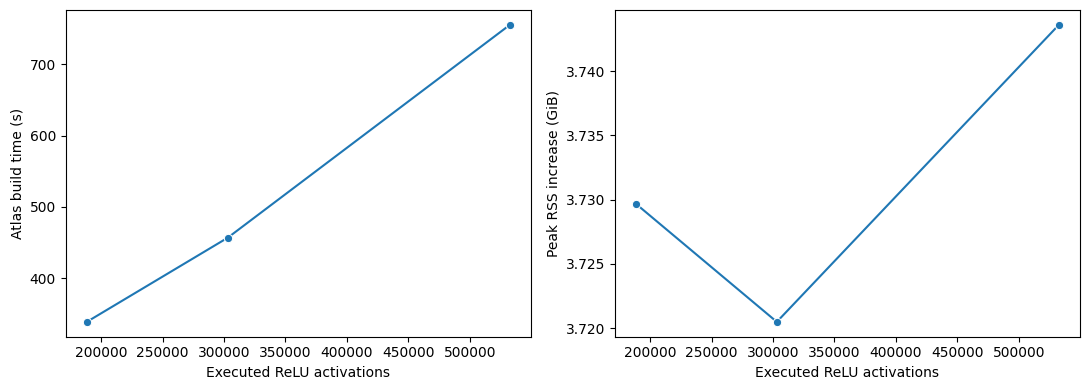

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=summary, x='relu_activation_count', y='build_wall_time_s', marker='o', ax=axes[0])
sns.lineplot(data=summary.assign(peak_rss_gib=summary.build_rss_peak_delta_bytes / 2**30), x='relu_activation_count', y='peak_rss_gib', marker='o', ax=axes[1])
axes[0].set(xlabel='Executed ReLU activations', ylabel='Atlas build time (s)')
axes[1].set(xlabel='Executed ReLU activations', ylabel='Peak RSS increase (GiB)')
plt.tight_layout()

## LiRPA coarseness and adaptive-epsilon diagnostics

,network,eps_initial_median,eps_final_median,eps_ratio_median,adaptive_shrinks_mean,uncertified_anchor_fraction
0,resnet20,84.65765,84.65765,1.00000,0.00000,0.00000
1,resnet32,84.65765,84.65765,1.00000,0.00000,0.00000
2,resnet56,84.65765,84.65765,1.00000,0.00000,0.00000


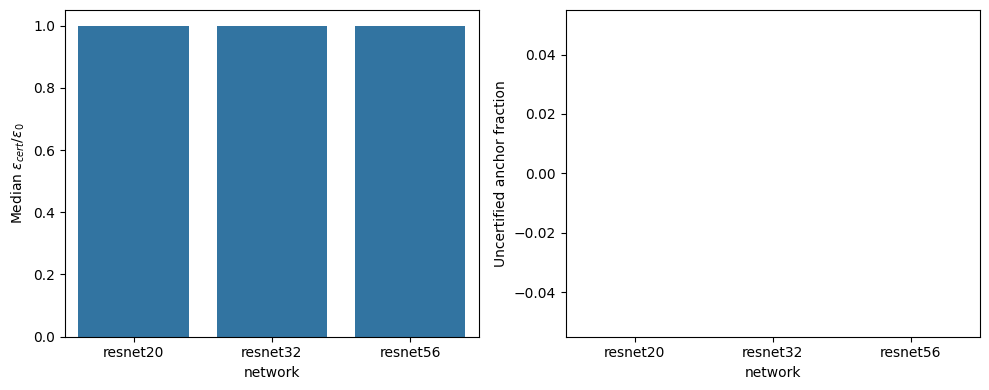

In [5]:
coarseness = summary[['network', 'eps_initial_median', 'eps_final_median', 'eps_ratio_median', 'adaptive_shrinks_mean', 'uncertified_anchor_fraction']]
display(coarseness.style.format(precision=5))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=summary, x='network', y='eps_ratio_median', ax=axes[0])
sns.barplot(data=summary, x='network', y='uncertified_anchor_fraction', ax=axes[1])
axes[0].set(ylabel=r'Median $\epsilon_{cert}/\epsilon_0$')
axes[1].set(ylabel='Uncertified anchor fraction')
plt.tight_layout()

## Counterfactual quality, robustness, and online time

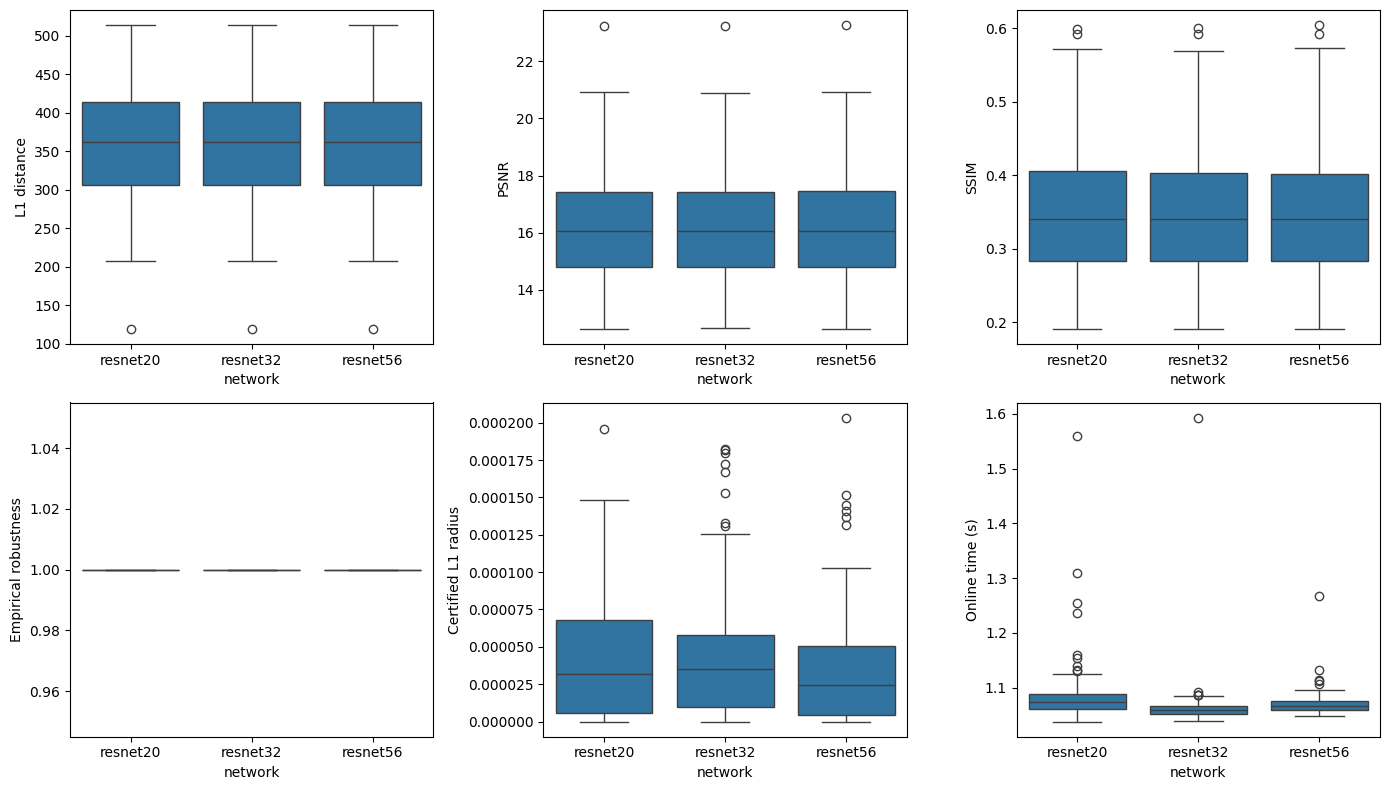

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, metric, label in zip(axes.flat, ['distance_l1', 'psnr', 'ssim', 'empirical_robustness', 'certified_l1_radius', 'runtime_s'], ['L1 distance', 'PSNR', 'SSIM', 'Empirical robustness', 'Certified L1 radius', 'Online time (s)']):
    sns.boxplot(data=queries, x='network', y=metric, order=NETWORK_ORDER, ax=ax)
    ax.set_ylabel(label)
plt.tight_layout()

## Matched qualitative examples

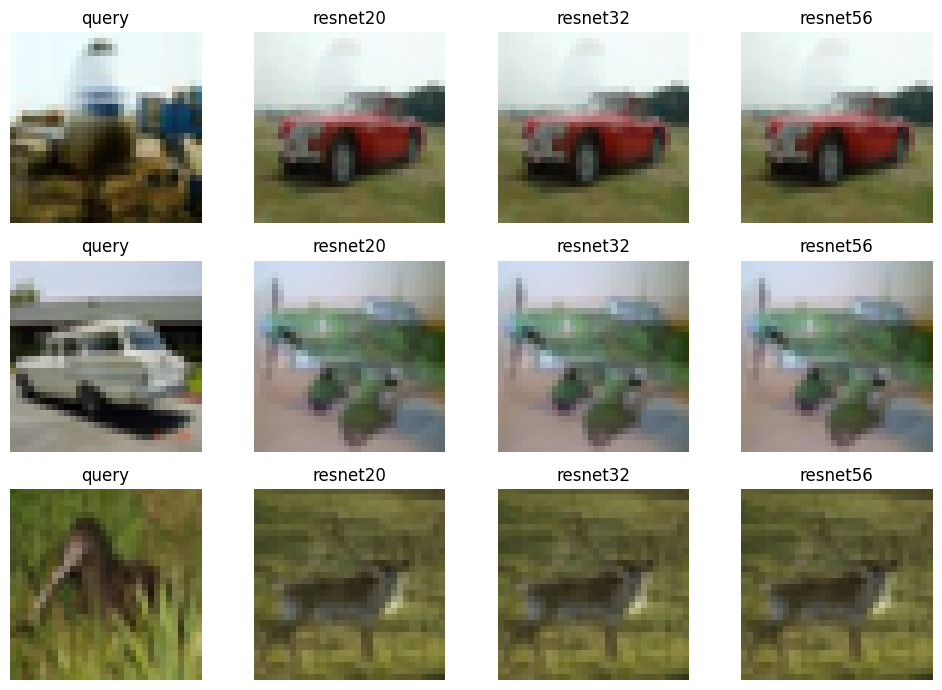

In [7]:
positions = [0, 10, 20]
fig, axes = plt.subplots(len(positions), 1 + len(NETWORK_ORDER), figsize=(10, 7))
for row, position in enumerate(positions):
    original = None
    for col, network in enumerate(NETWORK_ORDER, start=1):
        with np.load(RESULTS / 'networks' / network / 'queries' / f'query_{position:03d}.npz') as data:
            original = data['x'].reshape(3, 32, 32).transpose(1, 2, 0)
            cf = data['x_cf']
        axes[row, col].imshow(np.clip(cf.reshape(3, 32, 32).transpose(1, 2, 0), 0, 1)) if cf.size else axes[row, col].text(.5, .5, 'failure', ha='center')
        axes[row, col].set_title(network)
        axes[row, col].axis('off')
    axes[row, 0].imshow(original); axes[row, 0].set_title('query'); axes[row, 0].axis('off')
plt.tight_layout()

## Failures and resource limits

In [8]:
status_rows = []
for network in NETWORK_ORDER:
    path = RESULTS / 'networks' / network / 'build.json'
    status_rows.append(json.loads(path.read_text()) if path.exists() else {'network': network, 'status': 'missing'})
pd.DataFrame(status_rows)[[c for c in ['network', 'status', 'error', 'attempted_anchor_count', 'atlas_region_count', 'uncertified_anchor_count'] if c in pd.DataFrame(status_rows).columns]]

,network,status,attempted_anchor_count,atlas_region_count,uncertified_anchor_count
0,resnet20,complete,10000,10000,0
1,resnet32,complete,10000,10000,0
2,resnet56,complete,10000,10000,0
